STEP 1. LOADING DATA (FOR ME)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import polars as pl
from pathlib import Path

# Set up paths
base_dir = Path("..")
sample_train_path = base_dir / "data" / "sample" / "train_sample.parquet"
sample_test_path = base_dir / "data" / "sample" / "test_sample.parquet"
full_train_path = base_dir / "data" / "train.parquet"
full_test_path = base_dir / "data" / "test.parquet"

print("="*60)
print("loading full datasets - kaggle")
print("="*60)

# loading full datasets
train_full = pd.read_parquet(full_train_path)  
test_full = pd.read_parquet(full_test_path)

print(f" Train: {train_full.shape}")
print(f" Test: {test_full.shape}")

# Basic info
print(f"\n Train - columns: {train_full.columns.tolist()[:10]}...")
print(f" Test - columns: {test_full.columns.tolist()[:10]}...")

# Checking types of data
print(f"\n Types of data in train:")
print(train_full.dtypes.value_counts())

loading full datasets - kaggle
 Train: (5337414, 94)
 Test: (1447107, 92)

 Train - columns: ['id', 'code', 'sub_code', 'sub_category', 'horizon', 'ts_index', 'feature_a', 'feature_b', 'feature_c', 'feature_d']...
 Test - columns: ['id', 'code', 'sub_code', 'sub_category', 'horizon', 'ts_index', 'feature_a', 'feature_b', 'feature_c', 'feature_d']...

 Types of data in train:
float64    86
object      4
int32       3
int64       1
Name: count, dtype: int64


STEP 2: LOAD AND PROPERLY SORT BOTH SAMPLES

In [2]:
print("\n" + "="*60)
print("STEP 2: LOADING TRAIN AND TEST SAMPLES")
print("="*60)

# Load both samples
train_sample = pd.read_parquet(sample_train_path)
test_sample = pd.read_parquet(sample_test_path)

print(f" Train sample: {train_sample.shape}")
print(f" Test sample: {test_sample.shape}")

# PROPER SORTING - by all key columns
sort_cols = ['code', 'sub_code', 'sub_category', 'ts_index']
train_sample = train_sample.sort_values(sort_cols).reset_index(drop=True)
test_sample = test_sample.sort_values(sort_cols).reset_index(drop=True)

print(f"\n TRAIN SAMPLE - sorted by: {sort_cols}")
print(f"  - ts_index range: {train_sample['ts_index'].min()} to {train_sample['ts_index'].max()}")
print(f"  - Unique codes: {train_sample['code'].nunique()}")
print(f"  - Unique sub_codes: {train_sample['sub_code'].nunique()}")
print(f"  - sub_category:\n{train_sample['sub_category'].value_counts()}")

print(f"\n TEST SAMPLE - sorted by: {sort_cols}")
print(f"  - ts_index range: {test_sample['ts_index'].min()} to {test_sample['ts_index'].max()}")
print(f"  - Unique codes: {test_sample['code'].nunique()}")
print(f"  - Unique sub_codes: {test_sample['sub_code'].nunique()}")
print(f"  - sub_category:\n{test_sample['sub_category'].value_counts()}")

# Quick check of first few rows to verify sorting
print("\n First 5 rows of TRAIN (should be sorted by code, sub_code, sub_category, ts_index):")
print(train_sample[['code', 'sub_code', 'sub_category', 'ts_index']].head(10))

# Check missing values
for name, df in [('TRAIN', train_sample), ('TEST', test_sample)]:
    missing = df.isnull().sum().sum()
    missing_rows = df.isnull().any(axis=1).sum()
    print(f"\n {name} - missing values:")
    print(f"  Total missing cells: {missing}")
    print(f"  Rows with any missing: {missing_rows} ({missing_rows/len(df)*100:.2f}%)")


STEP 2: LOADING TRAIN AND TEST SAMPLES
 Train sample: (53374, 94)
 Test sample: (14471, 92)

 TRAIN SAMPLE - sorted by: ['code', 'sub_code', 'sub_category', 'ts_index']
  - ts_index range: 1 to 3601
  - Unique codes: 23
  - Unique sub_codes: 179
  - sub_category:
sub_category
NQ58FVQM    10828
PHHHVYZI    10736
PZ9S1Z4V    10701
V8BKY1IV    10563
DPPUO5X2    10546
Name: count, dtype: int64

 TEST SAMPLE - sorted by: ['code', 'sub_code', 'sub_category', 'ts_index']
  - ts_index range: 3602 to 4376
  - Unique codes: 23
  - Unique sub_codes: 47
  - sub_category:
sub_category
DPPUO5X2    2989
PZ9S1Z4V    2895
NQ58FVQM    2882
PHHHVYZI    2873
V8BKY1IV    2832
Name: count, dtype: int64

 First 5 rows of TRAIN (should be sorted by code, sub_code, sub_category, ts_index):
       code  sub_code sub_category  ts_index
0  10BAVIDU  236HB58W     NQ58FVQM      3536
1  10BAVIDU  236HB58W     NQ58FVQM      3564
2  10BAVIDU  236HB58W     NQ58FVQM      3570
3  10BAVIDU  236HB58W     NQ58FVQM      358

STEP 3: TASK 1 - IQR OUTLIER DETECTION


STEP 3: IQR OUTLIER DETECTION (Univariate)
Analyzing 86 numerical columns

 Calculating outliers for each column...
  feature_h: 918 outliers (1.72%)
  feature_i: 854 outliers (1.60%)
  feature_j: 4595 outliers (8.61%)
  feature_k: 2571 outliers (4.82%)
  feature_l: 596 outliers (1.12%)
  feature_m: 30 outliers (0.06%)
  feature_n: 19193 outliers (35.96%)
  feature_o: 8899 outliers (16.67%)
  feature_p: 8799 outliers (16.49%)
  feature_q: 6272 outliers (11.75%)
  feature_r: 9405 outliers (17.62%)
  feature_s: 6619 outliers (12.40%)
  feature_t: 8107 outliers (15.19%)
  feature_u: 9634 outliers (18.05%)
  feature_v: 4810 outliers (9.01%)
  feature_w: 9702 outliers (18.18%)
  feature_x: 14655 outliers (27.46%)
  feature_y: 14255 outliers (26.71%)
  feature_z: 13835 outliers (25.92%)
  feature_aa: 6145 outliers (11.51%)
  feature_ab: 6881 outliers (12.89%)
  feature_ac: 7765 outliers (14.55%)
  feature_ad: 8214 outliers (15.39%)
  feature_ae: 8007 outliers (15.00%)
  feature_af: 8840 out

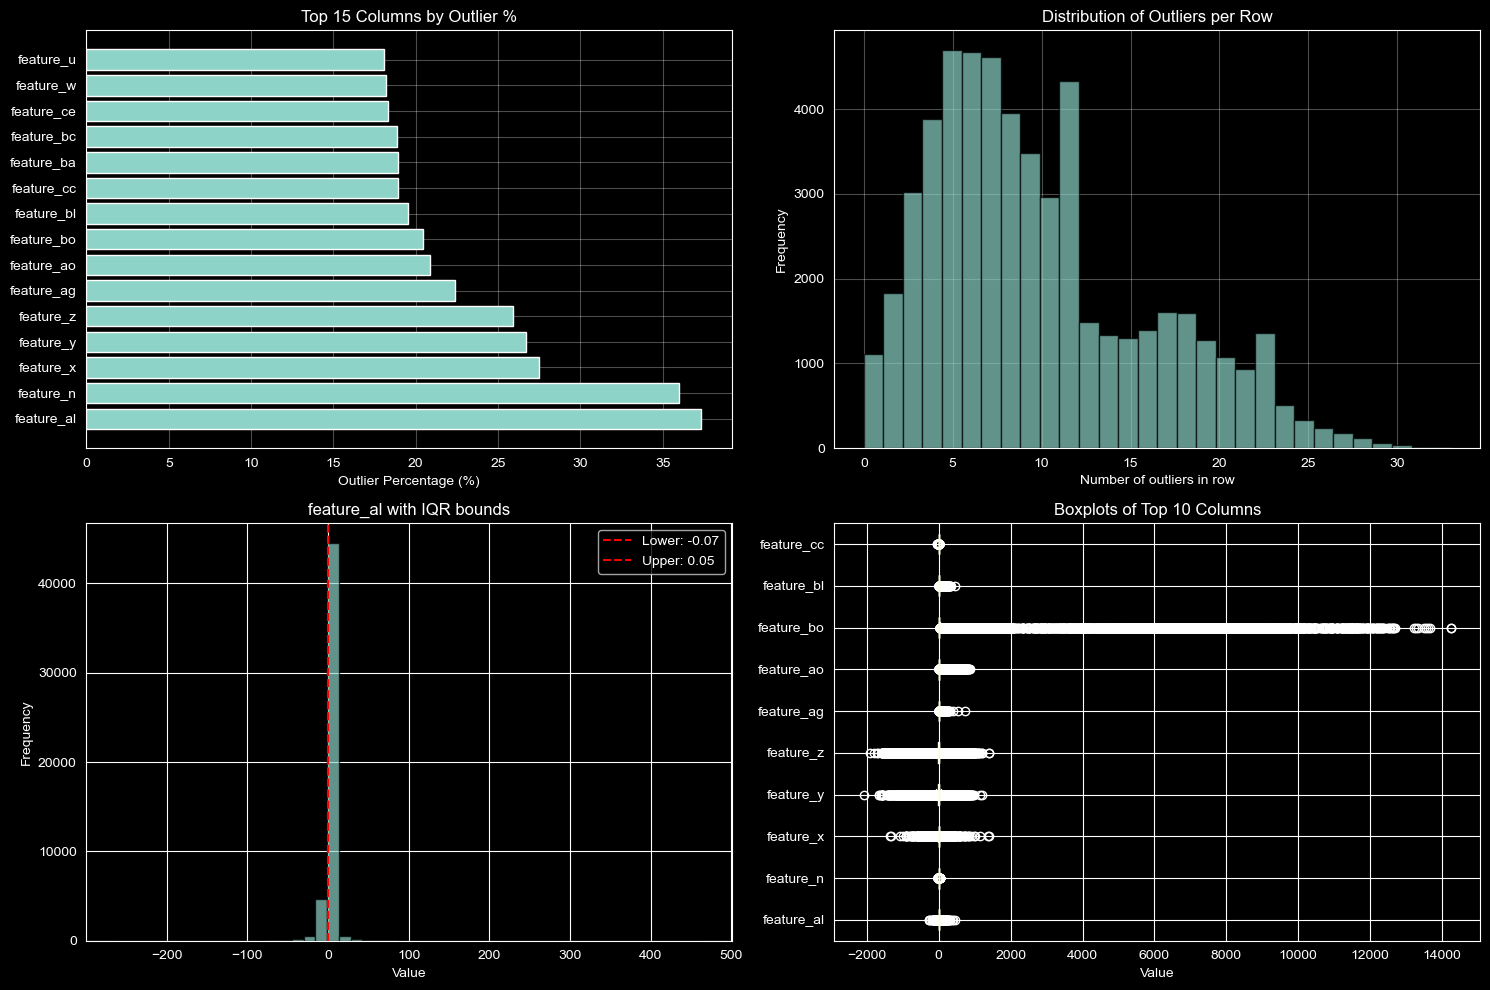


🔗 CORRELATION BETWEEN OUTLIER INDICATORS (top 10 columns):


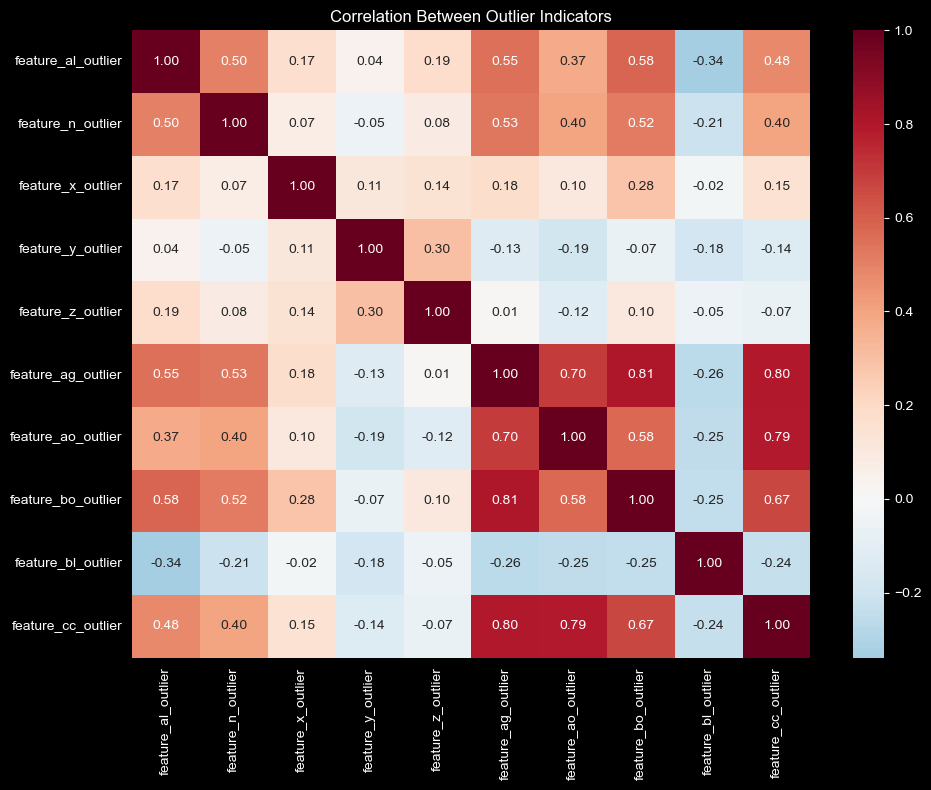


 IQR OUTLIER DETECTION SUMMARY:
  Total columns analyzed: 86
  Columns with any outliers: 75
  Average outlier % per column: 11.42%
  Median outlier % per column: 13.06%
  Max outlier %: 37.34%

 Saved IQR results to 'iqr_outlier_summary.csv'

 STEP 3 COMPLETE - IQR outlier detection finished


In [3]:
print("\n" + "="*60)
print("STEP 3: IQR OUTLIER DETECTION (Univariate)")
print("="*60)

# Select numerical columns (exclude id, categorical, and metadata)
exclude_cols = ['id', 'code', 'sub_code', 'sub_category', 'ts_index', 'horizon', 'y_target', 'weight']
feature_cols = [col for col in train_sample.columns if col.startswith('feature_')]
numeric_cols = feature_cols  # All feature_ columns are numerical

print(f"Analyzing {len(numeric_cols)} numerical columns")

# Function to detect IQR outliers
def detect_outliers_iqr(df, col, multiplier=1.5):
    """Detect outliers using Tukey's IQR method"""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
    return outliers, lower_bound, upper_bound, Q1, Q3, IQR

# Calculate outliers for all feature columns
outlier_results = []
outlier_mask = pd.DataFrame(index=train_sample.index)

print("\n Calculating outliers for each column...")
for col in numeric_cols:
    outliers, lower, upper, q1, q3, iqr = detect_outliers_iqr(train_sample, col)
    
    n_outliers = outliers.sum()
    pct_outliers = (n_outliers / len(train_sample)) * 100
    
    outlier_results.append({
        'column': col,
        'outliers_count': n_outliers,
        'outliers_pct': pct_outliers,
        'lower_bound': lower,
        'upper_bound': upper,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'min_val': train_sample[col].min(),
        'max_val': train_sample[col].max()
    })
    
    outlier_mask[f'{col}_outlier'] = outliers
    
    if n_outliers > 0:
        print(f"  {col}: {n_outliers} outliers ({pct_outliers:.2f}%)")

# Create summary DataFrame
outlier_summary = pd.DataFrame(outlier_results).sort_values('outliers_pct', ascending=False)

print("\n TOP 20 COLUMNS WITH MOST OUTLIERS:")
print(outlier_summary[['column', 'outliers_count', 'outliers_pct']].head(20).to_string())

# Calculate row-wise outlier count
outlier_mask['total_outliers_per_row'] = outlier_mask.sum(axis=1)
train_sample['iqr_outlier_count'] = outlier_mask['total_outliers_per_row']
train_sample['is_iqr_outlier'] = outlier_mask['total_outliers_per_row'] > 0

print(f"\n ROW-WISE STATISTICS:")
print(f"  Rows with at least one outlier: {train_sample['is_iqr_outlier'].sum()} ({train_sample['is_iqr_outlier'].mean()*100:.2f}%)")
print(f"  Average outliers per row: {outlier_mask['total_outliers_per_row'].mean():.2f}")
print(f"  Max outliers in single row: {outlier_mask['total_outliers_per_row'].max()}")

# Visualization 1: Distribution of outliers per column
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Bar plot of outlier percentages
top15 = outlier_summary.head(15)
axes[0, 0].barh(range(len(top15)), top15['outliers_pct'].values)
axes[0, 0].set_yticks(range(len(top15)))
axes[0, 0].set_yticklabels(top15['column'].values)
axes[0, 0].set_xlabel('Outlier Percentage (%)')
axes[0, 0].set_title('Top 15 Columns by Outlier %')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Distribution of outliers per row
axes[0, 1].hist(outlier_mask['total_outliers_per_row'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Number of outliers in row')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Outliers per Row')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Example column with outliers (first in top15)
example_col = top15.iloc[0]['column']
data = train_sample[example_col].dropna()
outliers, lower, upper, _, _, _ = detect_outliers_iqr(train_sample, example_col)

axes[1, 0].hist(data, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(lower, color='red', linestyle='--', label=f'Lower: {lower:.2f}')
axes[1, 0].axvline(upper, color='red', linestyle='--', label=f'Upper: {upper:.2f}')
axes[1, 0].set_title(f'{example_col} with IQR bounds')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Plot 4: Boxplot of top 10 columns
top10_cols = top15.head(10)['column'].values
box_data = [train_sample[col].dropna().values for col in top10_cols]
axes[1, 1].boxplot(box_data, labels=[c[:10] for c in top10_cols], vert=False)
axes[1, 1].set_title('Boxplots of Top 10 Columns')
axes[1, 1].set_xlabel('Value')
plt.tight_layout()
plt.show()

# Correlation between outlier indicators
print("\n🔗 CORRELATION BETWEEN OUTLIER INDICATORS (top 10 columns):")
top10_outlier_cols = [f'{col}_outlier' for col in top10_cols]
corr_matrix = outlier_mask[top10_outlier_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Between Outlier Indicators')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n IQR OUTLIER DETECTION SUMMARY:")
print(f"  Total columns analyzed: {len(numeric_cols)}")
print(f"  Columns with any outliers: {(outlier_summary['outliers_count'] > 0).sum()}")
print(f"  Average outlier % per column: {outlier_summary['outliers_pct'].mean():.2f}%")
print(f"  Median outlier % per column: {outlier_summary['outliers_pct'].median():.2f}%")
print(f"  Max outlier %: {outlier_summary['outliers_pct'].max():.2f}%")

# Save results for later use
outlier_summary.to_csv('iqr_outlier_summary.csv', index=False)
print(f"\n Saved IQR results to 'iqr_outlier_summary.csv'")

print("\n STEP 3 COMPLETE - IQR outlier detection finished")
print("="*60)

STEP 4: TASK 2 - LOCAL OUTLIER FACTOR


STEP 4: LOCAL OUTLIER FACTOR (Multivariate)

 Preparing data for LOF...
Total feature columns: 86
X shape: (53374, 86)

 Standardizing features...
 Standardization complete

 Applying PCA (reduce to 10 components)...
X_pca shape: (53374, 10)
Explained variance: 48.06%

 Applying LOF...

 LOF completed in 1.74 seconds
  n_neighbors=20, contamination=0.05
  Outliers: 2669 (5.00%)

 Visualizing LOF results...


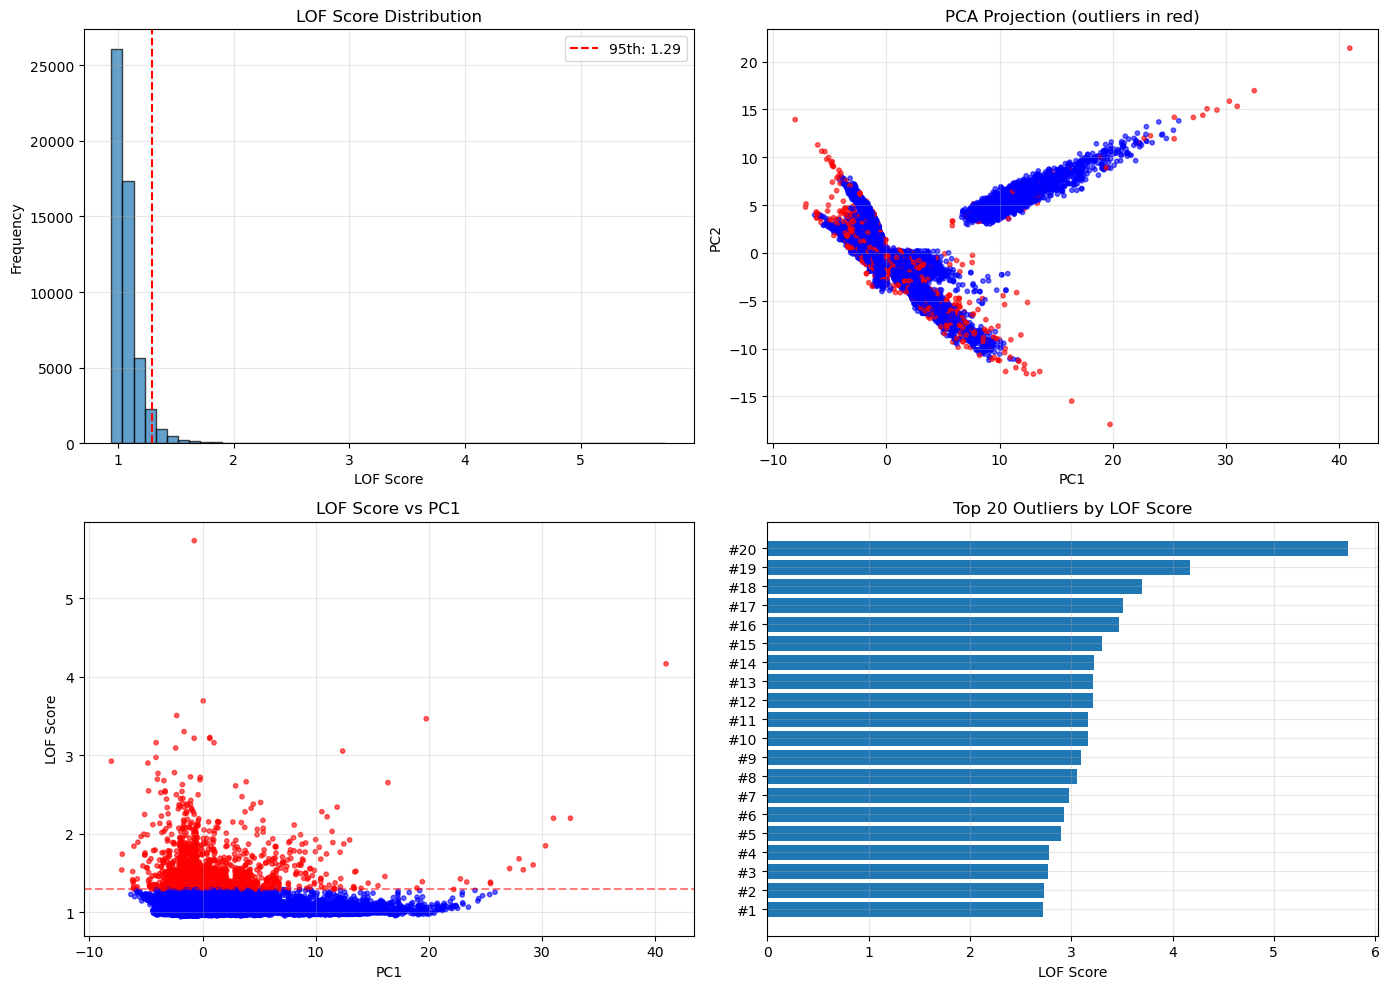


 LOF SCORE STATISTICS:
  Min: 0.9413
  Max: 5.7374
  Mean: 1.0775
  Median: 1.0391
  95th percentile: 1.2925
  99th percentile: 1.5764

 Quick comparison with IQR:
  Both methods: 2664 (4.99%)
  IQR only: 50505 (94.62%)
  LOF only: 5 (0.01%)
  Neither: 200 (0.37%)

 Saved LOF results to 'lof_results.csv'

 STEP 4 COMPLETE - LOF outlier detection finished


In [5]:
# ============================================
# STEP 4: LOCAL OUTLIER FACTOR (Simplified)
# ============================================
print("\n" + "="*60)
print("STEP 4: LOCAL OUTLIER FACTOR (Multivariate)")
print("="*60)

from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import time

# ============================================
# 1. Prepare data for LOF
# ============================================
print("\n Preparing data for LOF...")

# Select feature columns
feature_cols = [col for col in train_sample.columns if col.startswith('feature_')]
print(f"Total feature columns: {len(feature_cols)}")

# Handle missing values - fill with median
X = train_sample[feature_cols].fillna(train_sample[feature_cols].median()).values
print(f"X shape: {X.shape}")

# ============================================
# 2. Standardize features
# ============================================
print("\n Standardizing features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(" Standardization complete")

# ============================================
# 3. PCA for dimensionality reduction
# ============================================
print("\n Applying PCA (reduce to 10 components)...")

# Fixed number of components for speed and stability
n_components = 10
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
print(f"X_pca shape: {X_pca.shape}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# ============================================
# 4. Apply LOF with fixed parameters
# ============================================
print("\n Applying LOF...")

# Fixed parameters that work well
n_neighbors = 20
contamination = 0.05

start_time = time.time()

lof = LocalOutlierFactor(
    n_neighbors=n_neighbors, 
    contamination=contamination,
    n_jobs=-1  # Use all CPU cores
)
y_pred = lof.fit_predict(X_pca)
lof_scores = -lof.negative_outlier_factor_

elapsed = time.time() - start_time

n_outliers = (y_pred == -1).sum()
pct_outliers = n_outliers / len(X) * 100

print(f"\n LOF completed in {elapsed:.2f} seconds")
print(f"  n_neighbors={n_neighbors}, contamination={contamination}")
print(f"  Outliers: {n_outliers} ({pct_outliers:.2f}%)")

# Add to dataframe
train_sample['lof_outlier'] = (y_pred == -1)
train_sample['lof_score'] = lof_scores

# ============================================
# 5. Visualize LOF results
# ============================================
print("\n Visualizing LOF results...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: LOF score distribution
axes[0, 0].hist(lof_scores, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(np.percentile(lof_scores, 95), color='red', linestyle='--', 
                   label=f'95th: {np.percentile(lof_scores, 95):.2f}')
axes[0, 0].set_xlabel('LOF Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('LOF Score Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: PCA projection with outliers
colors = ['blue' if not x else 'red' for x in train_sample['lof_outlier']]
axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=10, alpha=0.6)
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')
axes[0, 1].set_title(f'PCA Projection (outliers in red)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: LOF score vs PC1
axes[1, 0].scatter(X_pca[:, 0], lof_scores, c=colors, s=10, alpha=0.6)
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('LOF Score')
axes[1, 0].set_title('LOF Score vs PC1')
axes[1, 0].axhline(y=np.percentile(lof_scores, 95), color='red', linestyle='--', alpha=0.5)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Top outliers by LOF score
top_n = 20
top_indices = np.argsort(lof_scores)[-top_n:]
axes[1, 1].barh(range(top_n), lof_scores[top_indices])
axes[1, 1].set_yticks(range(top_n))
axes[1, 1].set_yticklabels([f'#{i+1}' for i in range(top_n)])
axes[1, 1].set_xlabel('LOF Score')
axes[1, 1].set_title(f'Top {top_n} Outliers by LOF Score')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 6. LOF Score Statistics
# ============================================
print("\n LOF SCORE STATISTICS:")
print(f"  Min: {lof_scores.min():.4f}")
print(f"  Max: {lof_scores.max():.4f}")
print(f"  Mean: {lof_scores.mean():.4f}")
print(f"  Median: {np.median(lof_scores):.4f}")
print(f"  95th percentile: {np.percentile(lof_scores, 95):.4f}")
print(f"  99th percentile: {np.percentile(lof_scores, 99):.4f}")

# ============================================
# 7. Compare with IQR (quick preview)
# ============================================
if 'is_iqr_outlier' in train_sample.columns:
    print("\n Quick comparison with IQR:")
    both = (train_sample['is_iqr_outlier'] & train_sample['lof_outlier']).sum()
    iqr_only = (train_sample['is_iqr_outlier'] & ~train_sample['lof_outlier']).sum()
    lof_only = (~train_sample['is_iqr_outlier'] & train_sample['lof_outlier']).sum()
    neither = (~train_sample['is_iqr_outlier'] & ~train_sample['lof_outlier']).sum()
    total = len(train_sample)
    
    print(f"  Both methods: {both} ({both/total*100:.2f}%)")
    print(f"  IQR only: {iqr_only} ({iqr_only/total*100:.2f}%)")
    print(f"  LOF only: {lof_only} ({lof_only/total*100:.2f}%)")
    print(f"  Neither: {neither} ({neither/total*100:.2f}%)")

# ============================================
# 8. Save results
# ============================================
# Save LOF results
lof_output = pd.DataFrame({
    'lof_score': lof_scores,
    'is_lof_outlier': train_sample['lof_outlier']
})
lof_output.to_csv('lof_results.csv', index=False)
print(f"\n Saved LOF results to 'lof_results.csv'")

print("\n STEP 4 COMPLETE - LOF outlier detection finished")
print("="*60)

STEP 5: TASK 3 - COMPARISON OF IQR vs LOF


STEP 5: COMPARISON OF IQR vs LOF METHODS

 DETAILED COMPARISON:

Confusion Matrix:
             Not LOF  LOF Outlier  Total
Not IQR          200            5    205
IQR Outlier    50505         2664  53169
Total          50705         2669  53374

 AGREEMENT METRICS:
  Both methods agree: 2864 (5.37%)
  Both detect as outlier: 2664 (4.99%)
  Both detect as normal: 200 (0.37%)
  Disagreement: 50510 (94.63%)
    - IQR only: 50505 (94.62%)
    - LOF only: 5 (0.01%)

 Cohen's Kappa: 0.0002
  Interpretation: Slight agreement

 Creating visualizations...


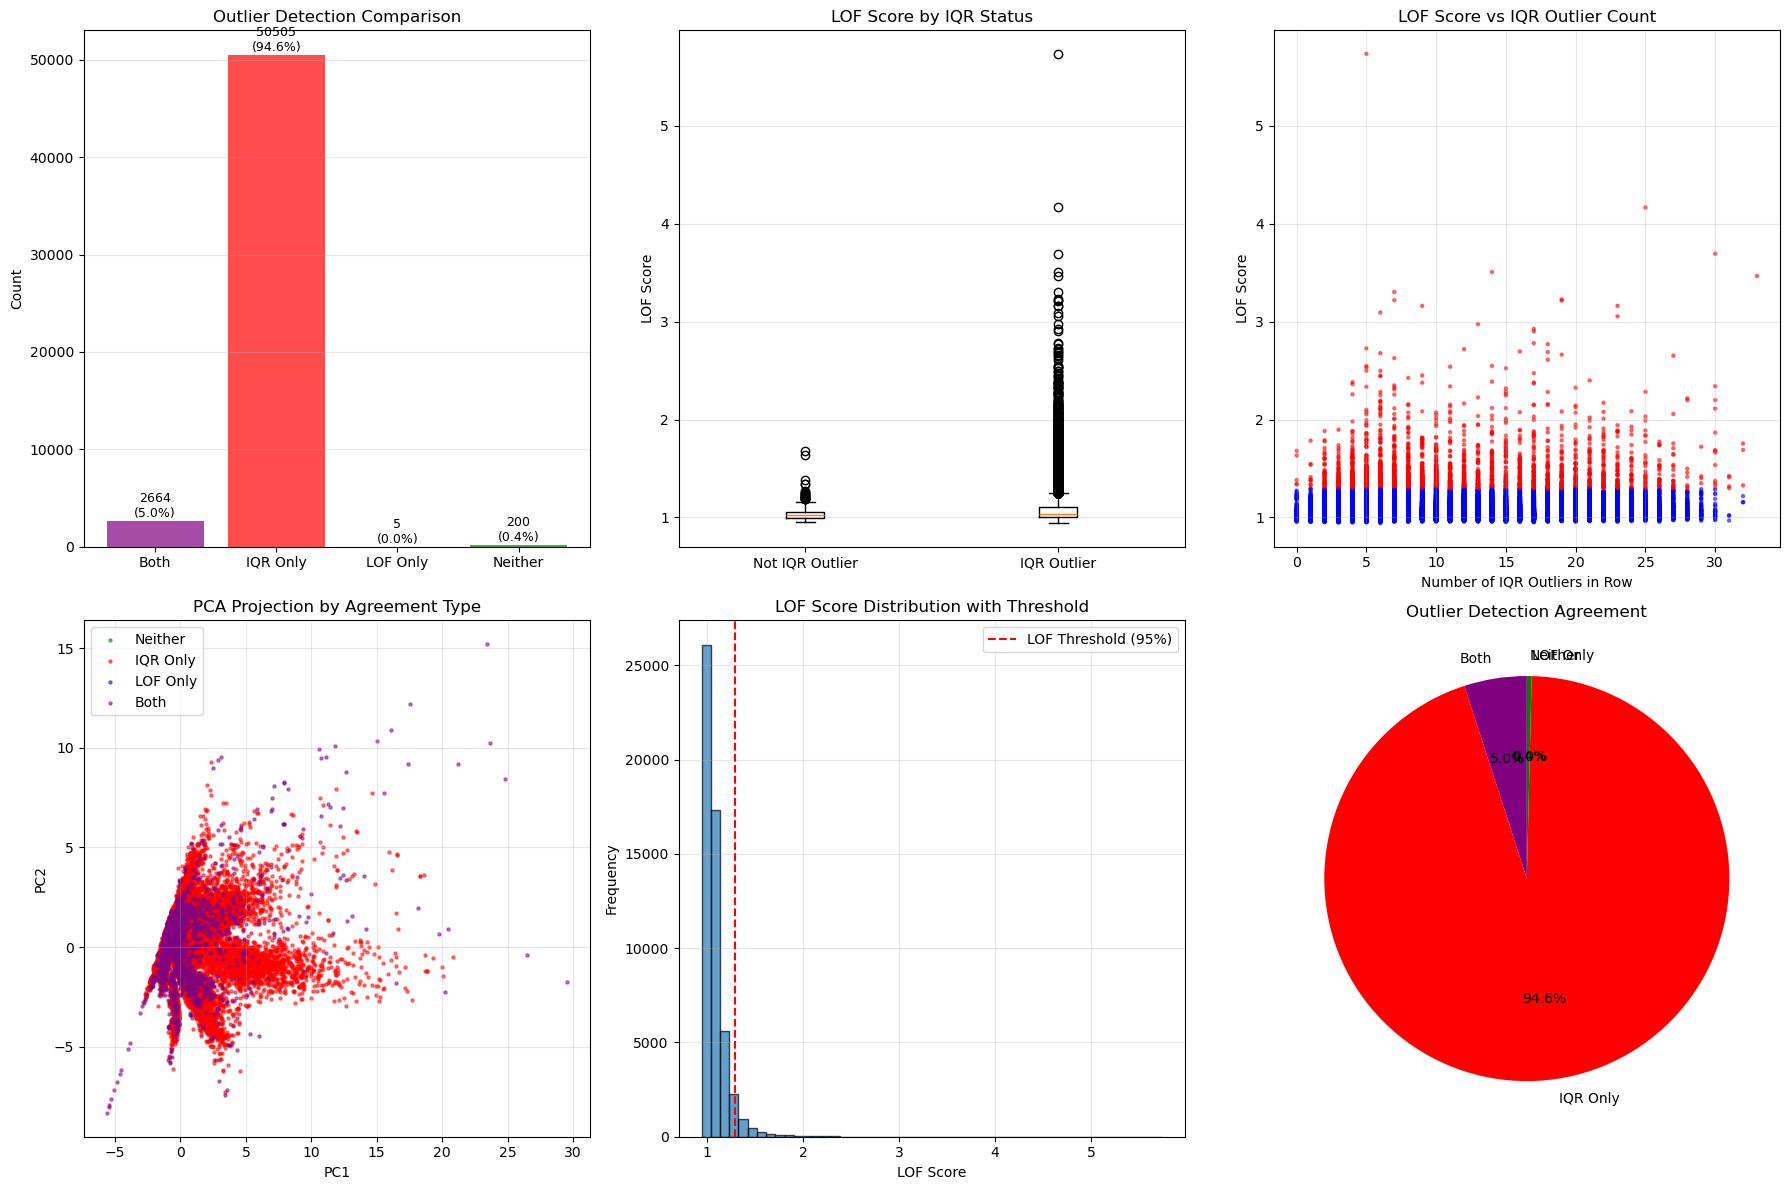


 STATISTICAL SUMMARY:
  Total samples: 53374
  IQR outliers: 53169 (99.62%)
  LOF outliers: 2669 (5.00%)
  Agreement rate: 5.37%
  Disagreement rate: 94.63%

 Saved comparison to 'outlier_comparison.csv'

 STEP 5 COMPLETE - Method comparison finished


In [6]:
print("\n" + "="*60)
print("STEP 5: COMPARISON OF IQR vs LOF METHODS")
print("="*60)

# ============================================
# 1. Detailed comparison table
# ============================================
print("\n DETAILED COMPARISON:")

# Create confusion matrix
comparison = pd.crosstab(
    train_sample['is_iqr_outlier'], 
    train_sample['lof_outlier'],
    margins=True
)
comparison.index = ['Not IQR', 'IQR Outlier', 'Total']
comparison.columns = ['Not LOF', 'LOF Outlier', 'Total']

print("\nConfusion Matrix:")
print(comparison)

# Calculate metrics
total = len(train_sample)
both = (train_sample['is_iqr_outlier'] & train_sample['lof_outlier']).sum()
iqr_only = (train_sample['is_iqr_outlier'] & ~train_sample['lof_outlier']).sum()
lof_only = (~train_sample['is_iqr_outlier'] & train_sample['lof_outlier']).sum()
neither = (~train_sample['is_iqr_outlier'] & ~train_sample['lof_outlier']).sum()

print(f"\n AGREEMENT METRICS:")
print(f"  Both methods agree: {both + neither} ({(both + neither)/total*100:.2f}%)")
print(f"  Both detect as outlier: {both} ({both/total*100:.2f}%)")
print(f"  Both detect as normal: {neither} ({neither/total*100:.2f}%)")
print(f"  Disagreement: {iqr_only + lof_only} ({(iqr_only + lof_only)/total*100:.2f}%)")
print(f"    - IQR only: {iqr_only} ({iqr_only/total*100:.2f}%)")
print(f"    - LOF only: {lof_only} ({lof_only/total*100:.2f}%)")

# Cohen's Kappa (agreement beyond chance)
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(train_sample['is_iqr_outlier'], train_sample['lof_outlier'])
print(f"\n Cohen's Kappa: {kappa:.4f}")
if kappa < 0:
    print("  Interpretation: Poor agreement")
elif kappa < 0.2:
    print("  Interpretation: Slight agreement")
elif kappa < 0.4:
    print("  Interpretation: Fair agreement")
elif kappa < 0.6:
    print("  Interpretation: Moderate agreement")
elif kappa < 0.8:
    print("  Interpretation: Substantial agreement")
else:
    print("  Interpretation: Almost perfect agreement")

# ============================================
# 2. Visual comparison
# ============================================
print("\n Creating visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Venn diagram (bar chart version)
categories = ['Both', 'IQR Only', 'LOF Only', 'Neither']
counts = [both, iqr_only, lof_only, neither]
colors = ['purple', 'red', 'blue', 'green']

bars = axes[0, 0].bar(categories, counts, color=colors, alpha=0.7)
axes[0, 0].set_title('Outlier Detection Comparison')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Add percentage labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 100,
                    f'{count}\n({count/total*100:.1f}%)', 
                    ha='center', va='bottom', fontsize=9)

# Plot 2: LOF score distribution by IQR status
train_sample_box = train_sample.copy()
axes[0, 1].boxplot([
    train_sample_box[~train_sample_box['is_iqr_outlier']]['lof_score'].dropna(),
    train_sample_box[train_sample_box['is_iqr_outlier']]['lof_score'].dropna()
], labels=['Not IQR Outlier', 'IQR Outlier'])
axes[0, 1].set_title('LOF Score by IQR Status')
axes[0, 1].set_ylabel('LOF Score')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Scatter plot of LOF score vs IQR outlier count
axes[0, 2].scatter(
    train_sample['iqr_outlier_count'], 
    train_sample['lof_score'],
    c=['red' if x else 'blue' for x in train_sample['lof_outlier']],
    alpha=0.5, s=5
)
axes[0, 2].set_xlabel('Number of IQR Outliers in Row')
axes[0, 2].set_ylabel('LOF Score')
axes[0, 2].set_title('LOF Score vs IQR Outlier Count')
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: PCA with coloring by agreement type
from sklearn.decomposition import PCA

# Create agreement categories
train_sample['agreement'] = 'Neither'
train_sample.loc[train_sample['is_iqr_outlier'] & ~train_sample['lof_outlier'], 'agreement'] = 'IQR Only'
train_sample.loc[~train_sample['is_iqr_outlier'] & train_sample['lof_outlier'], 'agreement'] = 'LOF Only'
train_sample.loc[train_sample['is_iqr_outlier'] & train_sample['lof_outlier'], 'agreement'] = 'Both'

# PCA for visualization
feature_cols = [col for col in train_sample.columns if col.startswith('feature_')][:20]
X_pca_viz = train_sample[feature_cols].fillna(0).values
scaler = StandardScaler()
X_scaled_viz = scaler.fit_transform(X_pca_viz)
pca_viz = PCA(n_components=2)
X_pca_2d = pca_viz.fit_transform(X_scaled_viz)

# Plot
colors_map = {'Neither': 'green', 'IQR Only': 'red', 'LOF Only': 'blue', 'Both': 'purple'}
for category, color in colors_map.items():
    mask = train_sample['agreement'] == category
    axes[1, 0].scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        c=color, label=category, alpha=0.5, s=5
    )
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
axes[1, 0].set_title('PCA Projection by Agreement Type')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: LOF score histogram with threshold
axes[1, 1].hist(train_sample['lof_score'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(train_sample['lof_score'].quantile(0.95), 
                   color='red', linestyle='--', label='LOF Threshold (95%)')
axes[1, 1].set_xlabel('LOF Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('LOF Score Distribution with Threshold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Summary pie chart
axes[1, 2].pie(
    [both, iqr_only, lof_only, neither],
    labels=['Both', 'IQR Only', 'LOF Only', 'Neither'],
    autopct='%1.1f%%',
    colors=['purple', 'red', 'blue', 'green'],
    startangle=90
)
axes[1, 2].set_title('Outlier Detection Agreement')

plt.tight_layout()
plt.show()

# ============================================
# 3. Statistical summary
# ============================================
print("\n STATISTICAL SUMMARY:")
print(f"  Total samples: {total}")
print(f"  IQR outliers: {train_sample['is_iqr_outlier'].sum()} ({train_sample['is_iqr_outlier'].mean()*100:.2f}%)")
print(f"  LOF outliers: {train_sample['lof_outlier'].sum()} ({train_sample['lof_outlier'].mean()*100:.2f}%)")
print(f"  Agreement rate: {(both + neither)/total*100:.2f}%")
print(f"  Disagreement rate: {(iqr_only + lof_only)/total*100:.2f}%")

# ============================================
# 4. Save comparison results
# ============================================
comparison_summary = pd.DataFrame({
    'metric': ['both', 'iqr_only', 'lof_only', 'neither', 'total'],
    'count': [both, iqr_only, lof_only, neither, total],
    'percentage': [both/total*100, iqr_only/total*100, lof_only/total*100, neither/total*100, 100]
})
comparison_summary.to_csv('outlier_comparison.csv', index=False)
print(f"\n Saved comparison to 'outlier_comparison.csv'")

print("\n STEP 5 COMPLETE - Method comparison finished")
print("="*60)

SPECIAL TREATMENT FOR NEGATIVE HYPERGEOMETRIC

In [7]:
def handle_negative_hypergeometric(df, col):
    """
    Special handling for the negative hypergeometric distribution
    """
    data = df[col].copy()
    
    # Option 1: Log transform (classic approach)
    df[col + '_log'] = np.log1p(data)  # log(1+x)
    
    # Option 2: Rank-based (preserves order, removes scale)
    df[col + '_rank'] = data.rank(pct=True)
    
    # Option 3: Binary features for thresholds
    thresholds = [data.quantile(0.5), data.quantile(0.9), data.quantile(0.99)]
    df[col + '_above_median'] = (data > thresholds[0]).astype(int)
    df[col + '_above_p90'] = (data > thresholds[1]).astype(int)
    df[col + '_above_p99'] = (data > thresholds[2]).astype(int)
    
    # Option 4: Keep original + add transformed
    # (model will choose what's best)
    
    return df

In [11]:
# identify columns with potential negative hypergeometric distribution
nhg_cols = ['feature_ba', 'feature_bd', 'feature_be', 'feature_bf', 'feature_bh',
            'feature_bc', 'feature_bb', 'feature_bk', 'feature_bj', 'feature_au',
            'feature_aw', 'feature_ax', 'feature_av', 'feature_ay', 'feature_at',
            'feature_bi']

for col in nhg_cols:
    # check for negative hypergeometric pattern: non-negative values with a long tail of small values and few large outliers
    is_nhg = (train_sample[col].min() >= 0) and \
             (train_sample[col].quantile(0.5) < train_sample[col].quantile(0.95) * 0.1)
    
    if is_nhg:
        print(f"\n {col}: Negative Hypergeometric detected")
        print(f"  Median: {train_sample[col].median():.0f}")
        print(f"  P95: {train_sample[col].quantile(0.95):.0f}")
        print(f"  Ratio P95/Median: {train_sample[col].quantile(0.95)/train_sample[col].median():.1f}x")
        
        # Dodaj transformacje
        train_sample = handle_negative_hypergeometric(train_sample, col)


 feature_ba: Negative Hypergeometric detected
  Median: 212
  P95: 128678
  Ratio P95/Median: 607.5x

 feature_bd: Negative Hypergeometric detected
  Median: 183310
  P95: 3908610
  Ratio P95/Median: 21.3x

 feature_be: Negative Hypergeometric detected
  Median: 124447
  P95: 2428344
  Ratio P95/Median: 19.5x

 feature_bf: Negative Hypergeometric detected
  Median: 82438
  P95: 2000424
  Ratio P95/Median: 24.3x

 feature_bh: Negative Hypergeometric detected
  Median: 60757
  P95: 1924266
  Ratio P95/Median: 31.7x

 feature_bc: Negative Hypergeometric detected
  Median: 67
  P95: 76536
  Ratio P95/Median: 1146.4x

 feature_bb: Negative Hypergeometric detected
  Median: 225
  P95: 28349
  Ratio P95/Median: 126.0x

 feature_bk: Negative Hypergeometric detected
  Median: 1102
  P95: 82561
  Ratio P95/Median: 74.9x

 feature_bj: Negative Hypergeometric detected
  Median: 710
  P95: 44391
  Ratio P95/Median: 62.5x

 feature_au: Negative Hypergeometric detected
  Median: 762
  P95: 34285
  R

In [8]:
missing_train = train_full.isnull().sum()
missing_test = test_full.isnull().sum()

In [11]:
# Ustawienie braku limitu wyświetlanych wierszy
pd.set_option('display.max_rows', None)

with pd.option_context('display.max_rows', None):
    print("\n Train:")      
    print(missing_train)
    print("\n Test:")      
    print(missing_test)


 Train:
id                   0
code                 0
sub_code             0
sub_category         0
horizon              0
ts_index             0
feature_a            0
feature_b            0
feature_c            0
feature_d            0
feature_e            0
feature_f            0
feature_g            0
feature_h        58465
feature_i        59025
feature_j        58465
feature_k        59025
feature_l         1300
feature_m        38170
feature_n         8906
feature_o         6258
feature_p         6362
feature_q         7122
feature_r         8906
feature_s         6258
feature_t         6362
feature_u         7122
feature_v         6154
feature_w         6184
feature_x         6184
feature_y         6184
feature_z         6184
feature_aa        6154
feature_ab        6362
feature_ac        7122
feature_ad        8906
feature_ae        8126
feature_af        8126
feature_ag        8126
feature_ah        6154
feature_ai           0
feature_aj        8126
feature_ak        8126
fe

In [18]:
print("\n Braki w Train (tylko kolumny z brakami):")
print(missing_train[missing_train > 0])
print("\n Train - shape of data with missing values:")
print(train_full.shape)

print("\n Braki w Test (tylko kolumny z brakami):")
print(missing_test[missing_test > 0])
print("\n Test - shape of data with missing values:")
print(test_full.shape)


 Braki w Train (tylko kolumny z brakami):
feature_h      58465
feature_i      59025
feature_j      58465
feature_k      59025
feature_l       1300
feature_m      38170
feature_n       8906
feature_o       6258
feature_p       6362
feature_q       7122
feature_r       8906
feature_s       6258
feature_t       6362
feature_u       7122
feature_v       6154
feature_w       6184
feature_x       6184
feature_y       6184
feature_z       6184
feature_aa      6154
feature_ab      6362
feature_ac      7122
feature_ad      8906
feature_ae      8126
feature_af      8126
feature_ag      8126
feature_ah      6154
feature_aj      8126
feature_ak      8126
feature_al    225416
feature_at    665676
feature_au     38447
feature_av     38654
feature_aw    205194
feature_ax     38409
feature_ay    455920
feature_az     11157
feature_bi    147432
feature_bj        40
feature_bl     11157
feature_by    588140
feature_bz    151722
feature_ca        40
feature_cc      2635
feature_cd    400114
feature_ce  

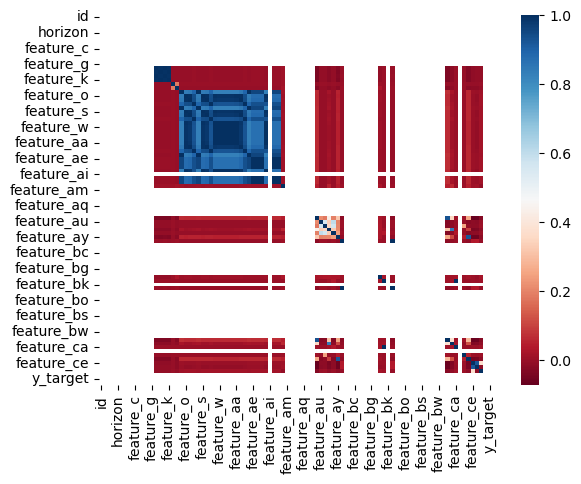

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Macierz korelacji braków (True/False)
missing_corr = train_full.isnull().corr()
sns.heatmap(missing_corr, cmap='RdBu')
plt.show()

In [20]:
# Czy tam gdzie jest brak, y_target ma inną średnią?
train_full['is_missing_at'] = train_full['feature_at'].isnull()
print(train_full.groupby('is_missing_at')['y_target'].mean())

is_missing_at
False   -0.756835
True    -0.027753
Name: y_target, dtype: float64


In [21]:


# Wybieramy kolumny z największymi brakami (np. te powyżej 5%)
high_nan_cols = train_full.columns[train_full.isnull().mean() > 0.05].tolist()

# 1. Sprawdzamy czy braki zależą od sub_category
print("--- PROCENT BRAKÓW PER SUB_CATEGORY ---")
for col in high_nan_cols:
    nan_by_cat = train_full.groupby('sub_category')[col].apply(lambda x: x.isnull().mean() * 100)
    if nan_by_cat.std() > 5: # Drukuj tylko jeśli braki różnią się między kategoriami
        print(f"\nKolumna: {col}")
        print(nan_by_cat.sort_values(ascending=False).head(5))

# 2. Sprawdzamy czy braki są skorelowane z czasem (ts_index)
print("\n--- KORELACJA BRAKÓW Z TS_INDEX ---")
for col in high_nan_cols:
    is_missing = train_full[col].isnull().astype(int)
    corr_time = is_missing.corr(train_full['ts_index'])
    if abs(corr_time) > 0.1:
        print(f"Brak w {col} wykazuje trend czasowy: corr={corr_time:.3f}")

# 3. Sprawdzamy czy braki zależą od 'horizon' (ważne w prognozowaniu!)
print("\n--- BRAKI A HORIZON ---")
for col in high_nan_cols:
    nan_by_horizon = train_full.groupby('horizon')[col].apply(lambda x: x.isnull().mean() * 100)
    print(f"\nBraki w {col} na horyzontach:\n{nan_by_horizon}")


--- PROCENT BRAKÓW PER SUB_CATEGORY ---

--- KORELACJA BRAKÓW Z TS_INDEX ---
Brak w feature_at wykazuje trend czasowy: corr=-0.157
Brak w feature_ay wykazuje trend czasowy: corr=-0.152
Brak w feature_by wykazuje trend czasowy: corr=-0.233
Brak w feature_cd wykazuje trend czasowy: corr=-0.219

--- BRAKI A HORIZON ---

Braki w feature_at na horyzontach:
horizon
1     12.089315
3     12.150242
10    12.486352
25    13.258900
Name: feature_at, dtype: float64

Braki w feature_ay na horyzontach:
horizon
1     8.292815
3     8.333285
10    8.548155
25    9.057160
Name: feature_ay, dtype: float64

Braki w feature_by na horyzontach:
horizon
1     10.645157
3     10.703369
10    11.033879
25    11.789615
Name: feature_by, dtype: float64

Braki w feature_cd na horyzontach:
horizon
1     7.260301
3     7.297650
10    7.501443
25    7.986659
Name: feature_cd, dtype: float64

Braki w feature_ce na horyzontach:
horizon
1     5.117474
3     5.126943
10    5.174031
25    5.265108
Name: feature_ce, dtyp

In [22]:


# Wybieramy wszystkie kolumny, które mają JAKIEKOLWIEK braki
any_nan_cols = train_full.columns[train_full.isnull().any()].tolist()

results = []

for col in any_nan_cols:
    is_missing = train_full[col].isnull()
    
    # 1. Korelacja z czasem
    corr_ts = is_missing.corr(train_full['ts_index'])
    
    # 2. Czy braki skaczą na horyzoncie 25? (Różnica między max a min horyzontem)
    nan_by_hor = train_full.groupby('horizon')[col].apply(lambda x: x.isnull().mean())
    hor_gap = nan_by_hor.max() - nan_by_hor.min()
    
    # 3. Zmienność między kategoriami (czy jakaś kategoria ma wyjątkowo dużo braków?)
    nan_by_cat = train_full.groupby('sub_category')[col].apply(lambda x: x.isnull().mean())
    cat_std = nan_by_cat.std()

    results.append({
        'feature': col,
        'missing_count': is_missing.sum(),
        'missing_pct': is_missing.mean() * 100,
        'ts_corr': corr_ts,
        'hor_gap_pct': hor_gap * 100,
        'cat_volatility': cat_std
    })

# Tworzymy raport i sortujemy po tym, co "dziwne"
report = pd.DataFrame(results).sort_values(by='ts_corr', key=abs, ascending=False)

# Wyświetlamy te, które mają silny trend czasowy LUB duże różnice w horyzontach
print("--- ANALIZA 'PODSTĘPNYCH' BRAKÓW ---")
print(report[(report['ts_corr'].abs() > 0.05) | (report['hor_gap_pct'] > 0.5)].to_string())


--- ANALIZA 'PODSTĘPNYCH' BRAKÓW ---
       feature  missing_count  missing_pct   ts_corr  hor_gap_pct  cat_volatility
40  feature_by         588140    11.019194 -0.232642     1.144458        0.000436
44  feature_cd         400114     7.496402 -0.219260     0.726359        0.000188
30  feature_at         665676    12.471882 -0.157049     1.169585        0.000491
35  feature_ay         455920     8.541964 -0.151625     0.764345        0.000167
31  feature_au          38447     0.720330  0.119281     0.016121        0.000035
34  feature_ax          38409     0.719618  0.117675     0.010812        0.000031
32  feature_av          38654     0.724208  0.105897     0.006669        0.000157
41  feature_bz         151722     2.842613 -0.079479     0.344959        0.000361
6    feature_n           8906     0.166860 -0.052280     0.018108        0.000027
10   feature_r           8906     0.166860 -0.052280     0.018108        0.000027
22  feature_ad           8906     0.166860 -0.052280     0.01

In [23]:
for col in ['feature_at', 'feature_ay', 'feature_by']:
    print(f"Średnia waga dla braków w {col}:")
    print(train_full.groupby(train_full[col].isnull())['weight'].mean())

Średnia waga dla braków w feature_at:
feature_at
False    1.459709e+07
True     2.927644e+07
Name: weight, dtype: float64
Średnia waga dla braków w feature_ay:
feature_ay
False    1.711840e+07
True     9.034504e+06
Name: weight, dtype: float64
Średnia waga dla braków w feature_by:
feature_by
False    1.434089e+07
True     3.328049e+07
Name: weight, dtype: float64


wypełniam braki mote carlo szpileczką

In [24]:
import numpy as np

def smart_impute(df, col):
    # 1. Dodaj flagę dla wysokowagowych braków
    if col in ['feature_at', 'feature_by', 'feature_al']:
        df[f'{col}_is_nan'] = df[col].isnull().astype(np.int8)
    
    # 2. Warstwowe Monte Carlo (per horizon)
    def mc_fill(group):
        nans = group.isnull()
        if nans.any():
            valid_data = group.dropna()
            if not valid_data.empty:
                # Losujemy ze zwracaniem z istniejących wartości w tej grupie
                replacement = np.random.choice(valid_data, size=nans.sum(), replace=True)
                group[nans] = replacement
            else:
                # Jeśli cała grupa jest pusta, dajemy zero/medianę globalną
                group = group.fillna(0)
        return group

    # Grupowanie po horizon zachowuje specyfikę przedziałów czasowych
    return df.groupby('horizon')[col].transform(mc_fill)

# Zastosuj dla kluczowych kolumn
for c in ['feature_at', 'feature_by', 'feature_al', 'feature_ay']:
    train_full[c] = smart_impute(train_full, c)


COMPLETE MISSING DATA ANALYSIS - ALL COLUMNS

In [ ]:
print("="*60)
print("MISSING DATA ANALYSIS - FULL TRAIN DATASET")
print("="*60)

# ============================================
# 1. BASIC MISSING STATISTICS FOR ALL COLUMNS
# ============================================
missing = train_full.isnull().sum()
missing_pct = (missing / len(train_full)) * 100

missing_df = pd.DataFrame({
    'column': missing.index,
    'missing_count': missing.values,
    'missing_pct': missing_pct.values,
    'dtype': train_full.dtypes.values
}).sort_values('missing_pct', ascending=False)

print("\n ALL COLUMNS - MISSING DATA SUMMARY:")
print(missing_df.to_string())

# ============================================
# 2. CLASSIFICATION BY MULTIPLE CRITERIA
# ============================================
print("\n" + "="*60)
print("MULTI-CRITERIA CLASSIFICATION")
print("="*60)

# Define NHG columns (from your analysis)
nhg_cols = ['feature_ba', 'feature_bd', 'feature_be', 'feature_bf', 'feature_bh',
            'feature_bc', 'feature_bb', 'feature_bk', 'feature_bj', 'feature_au',
            'feature_aw', 'feature_ax', 'feature_av', 'feature_ay', 'feature_at',
            'feature_bi']

def classify_column(row):
    """Multi-criteria classification"""
    col = row['column']
    missing_pct = row['missing_pct']
    
    # Criteria 1: Is it NHG?
    is_nhg = col in nhg_cols
    
    # Criteria 2: Missing percentage
    if missing_pct == 0:
        missing_class = 'none'
    elif missing_pct < 1:
        missing_class = 'very_low'
    elif missing_pct < 5:
        missing_class = 'low'
    elif missing_pct < 10:
        missing_class = 'medium'
    elif missing_pct < 20:
        missing_class = 'high'
    else:
        missing_class = 'very_high'
    
    # Criteria 3: Data type
    dtype_class = str(row['dtype'])
    
    # Criteria 4: Column type
    if col.startswith('feature_'):
        col_type = 'feature'
    elif col in ['code', 'sub_code', 'sub_category']:
        col_type = 'categorical'
    elif col in ['ts_index', 'horizon']:
        col_type = 'temporal'
    elif col == 'y_target':
        col_type = 'target'
    elif col == 'weight':
        col_type = 'weight'
    elif col == 'id':
        col_type = 'identifier'
    else:
        col_type = 'other'
    
    return pd.Series({
        'is_nhg': is_nhg,
        'missing_class': missing_class,
        'dtype_class': dtype_class,
        'col_type': col_type
    })

# Apply classification
classification = missing_df.apply(classify_column, axis=1)
missing_df = pd.concat([missing_df, classification], axis=1)

print("\n📊 CLASSIFICATION SUMMARY:")
print(missing_df[['column', 'col_type', 'is_nhg', 'missing_class', 'dtype']].head(20).to_string())

# ============================================
# 3. STATISTICS BY CATEGORY
# ============================================
print("\n" + "="*60)
print("STATISTICS BY CATEGORY")
print("="*60)

print("\n📈 By column type:")
print(missing_df.groupby('col_type')['missing_pct'].agg(['count', 'mean', 'max']))

print("\n📈 By NHG status:")
print(missing_df.groupby('is_nhg')['missing_pct'].agg(['count', 'mean', 'max']))

print("\n📈 By missing class:")
print(missing_df.groupby('missing_class')['missing_pct'].agg(['count', 'mean', 'max']))

# ============================================
# 4. RECOMMENDATIONS BASED ON MULTIPLE CRITERIA
# ============================================
print("\n" + "="*60)
print("FINAL RECOMMENDATIONS")
print("="*60)

def get_recommendation(row):
    """Generate recommendation based on all criteria"""
    col = row['column']
    missing_pct = row['missing_pct']
    is_nhg = row['is_nhg']
    col_type = row['col_type']
    
    # Special cases
    if col_type == 'identifier':
        return 'drop_from_features'
    if col_type == 'target':
        return 'keep_original'
    if col_type == 'weight':
        return 'use_as_weight'
    
    # Missing-based recommendations
    if missing_pct == 0:
        imputation = 'none_needed'
    elif missing_pct < 1:
        imputation = 'median_by_group'
    elif missing_pct < 5:
        imputation = 'group_median_or_zeros'
    elif missing_pct < 10:
        imputation = 'distribution_sampling'
    elif missing_pct < 20:
        imputation = 'mcmc_on_sample'
    else:
        imputation = 'consider_dropping_column'
    
    # NHG-specific handling
    if is_nhg:
        if missing_pct < 5:
            final = f'NHG: {imputation} + keep_original_scale'
        elif missing_pct < 10:
            final = f'NHG: {imputation} + add_log_transform'
        else:
            final = f'NHG: {imputation} OR add_binary_flags'
    else:
        final = f'regular: {imputation}'
    
    # Data type recommendation
    if col_type not in ['feature', 'temporal']:
        dtype_rec = 'as_original'
    elif is_nhg:
        dtype_rec = 'float64'
    elif row['dtype'] in ['int64', 'int32'] and missing_pct == 0:
        dtype_rec = 'int32'
    elif row['max'] - row['min'] < 60000:
        dtype_rec = 'float16'
    elif row['max'] - row['min'] < 1e9:
        dtype_rec = 'float32'
    else:
        dtype_rec = 'float64'
    
    return pd.Series({
        'imputation_strategy': final,
        'recommended_dtype': dtype_rec,
        'priority': 'high' if missing_pct > 5 or is_nhg else 'normal'
    })

# Add min/max for dtype decisions
missing_df['min'] = train_full[missing_df['column']].min()
missing_df['max'] = train_full[missing_df['column']].max()
missing_df['range'] = missing_df['max'] - missing_df['min']

# Get recommendations
recommendations = missing_df.apply(get_recommendation, axis=1)
missing_df = pd.concat([missing_df, recommendations], axis=1)

# ============================================
# 5. FINAL REPORT
# ============================================
print("\n📋 FINAL RECOMMENDATIONS BY PRIORITY:")
print("\n🔴 HIGH PRIORITY COLUMNS:")
high_priority = missing_df[missing_df['priority'] == 'high']
print(high_priority[['column', 'missing_pct', 'imputation_strategy', 'recommended_dtype']].to_string())

print("\n🟡 NORMAL PRIORITY COLUMNS:")
normal_priority = missing_df[missing_df['priority'] == 'normal']
print(normal_priority[['column', 'missing_pct', 'imputation_strategy', 'recommended_dtype']].head(20).to_string())

print("\n🟢 COLUMNS WITH NO MISSING VALUES:")
no_missing = missing_df[missing_df['missing_pct'] == 0]
print(no_missing[['column', 'recommended_dtype']].head(20).to_string())

# ============================================
# 6. SUMMARY STATISTICS
# ============================================
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(f"\n📊 Total columns analyzed: {len(missing_df)}")
print(f"📊 Columns with any missing: {(missing_df['missing_pct'] > 0).sum()}")
print(f"📊 Columns with >10% missing: {(missing_df['missing_pct'] > 10).sum()}")
print(f"📊 NHG columns: {missing_df['is_nhg'].sum()}")
print(f"📊 NHG columns with >5% missing: {missing_df[missing_df['is_nhg'] & (missing_df['missing_pct'] > 5)].shape[0]}")

print("\n📈 RECOMMENDED DTYPES SUMMARY:")
print(missing_df['recommended_dtype'].value_counts())

print("\n📈 IMPUTATION STRATEGIES SUMMARY:")
print(missing_df['imputation_strategy'].apply(lambda x: x.split(':')[0]).value_counts())

# ============================================
# 7. SAVE REPORT
# ============================================
missing_df.to_csv('complete_missing_analysis.csv', index=False)
print("\n💾 Saved complete report to 'complete_missing_analysis.csv'")

print("\n✅ ANALYSIS COMPLETE")
print("="*60)

In [20]:
train_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5337414 entries, 0 to 5337413
Data columns (total 94 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            object 
 1   code          object 
 2   sub_code      object 
 3   sub_category  object 
 4   horizon       int32  
 5   ts_index      int32  
 6   feature_a     int32  
 7   feature_b     float64
 8   feature_c     float64
 9   feature_d     float64
 10  feature_e     float64
 11  feature_f     float64
 12  feature_g     float64
 13  feature_h     float64
 14  feature_i     float64
 15  feature_j     float64
 16  feature_k     float64
 17  feature_l     float64
 18  feature_m     float64
 19  feature_n     float64
 20  feature_o     float64
 21  feature_p     float64
 22  feature_q     float64
 23  feature_r     float64
 24  feature_s     float64
 25  feature_t     float64
 26  feature_u     float64
 27  feature_v     float64
 28  feature_w     float64
 29  feature_x     float64
 30  feature_y     floa

In [ ]:
test_full.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1447107 entries, 0 to 1447106
Data columns (total 92 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   id            1447107 non-null  object 
 1   code          1447107 non-null  object 
 2   sub_code      1447107 non-null  object 
 3   sub_category  1447107 non-null  object 
 4   horizon       1447107 non-null  int32  
 5   ts_index      1447107 non-null  int32  
 6   feature_a     1447107 non-null  int32  
 7   feature_b     1447107 non-null  float64
 8   feature_c     1447107 non-null  float64
 9   feature_d     1447107 non-null  float64
 10  feature_e     1447107 non-null  float64
 11  feature_f     1447107 non-null  float64
 12  feature_g     1447107 non-null  float64
 13  feature_h     1446927 non-null  float64
 14  feature_i     1446927 non-null  float64
 15  feature_j     1446927 non-null  float64
 16  feature_k     1446927 non-null  float64
 17  feature_l     1446880 non-n